In [40]:
from datasets import load_dataset
import imagehash, collections
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## Block 1

In [2]:
ds = load_dataset("as-cle-bert/banana-disease-classification")

README.md:   0%|          | 0.00/3.88k [00:00<?, ?B/s]

C:\Users\Acer\J26-IT-408\component-3\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Acer\.cache\huggingface\hub\datasets--as-cle-bert--banana-disease-classification. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
C:\Users\Acer\J26-IT-408\component-3\.venv\Lib\site-packages\huggingface_hub\file_d

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 30.1MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.09MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/700 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/77 [00:00<?, ? examples/s]

In [4]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 700
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 77
    })
})


In [6]:
names = ds["train"].features["label"].names
print(names)

['banana_healthy_leaf', 'black_sigatoka', 'bract_mosaic_virus', 'insect_pest', 'moko_disease', 'panama_disease', 'yellow_sigatoka']


In [7]:
seen, dups = {}, []
for split in ["train", "test"]:
    for i, ex in enumerate(ds[split]):
        h = str(imagehash.phash(ex["image"]))
        if h in seen: dups.append((split, i, seen[h]))
        else: seen[h] = (split, i)

In [8]:
print("near-duplicates:", len(dups))

near-duplicates: 7


## Block 2

In [31]:
path = Path.cwd().resolve().parent
print(path)

C:\Users\Acer\J26-IT-408\component-3


In [32]:
root = path/"data"/"raw"
print(root)

C:\Users\Acer\J26-IT-408\component-3\data\raw


In [33]:
rows = []
for split in ["train", "test"]:
    for i, ex in enumerate(ds[split]):
        img = ex["image"]
        cls = names[ex["label"]]
        folder = root / cls
        folder.mkdir(parents=True, exist_ok=True)
        fname = f"{split}_{i:04d}.png"          # row index lets you trace back to the dataset
        img.save(folder / fname)                # saved as-is, no resizing or colour conversion
        rows.append(dict(file=f"{cls}/{fname}", split=split, row=i, label=cls,
                         width=img.width, height=img.height, mode=img.mode,
                         phash=str(imagehash.phash(img))))

In [35]:
meta = pd.DataFrame(rows)
meta.to_csv("../data/raw_metadata.csv", index=False)
print(meta.shape)

(777, 8)


## Step 2: Investigate the 7 near-duplicates

In [36]:
d = meta[meta.duplicated("phash", keep=False)].sort_values("phash")
print(d[["file", "split", "label", "phash"]].to_string())

                                   file  split                label             phash
502       panama_disease/train_0502.png  train       panama_disease  853473c2679d49bc
755        panama_disease/test_0055.png   test       panama_disease  853473c2679d49bc
602      yellow_sigatoka/train_0602.png  train      yellow_sigatoka  8e5d05fb0ce318e3
766       yellow_sigatoka/test_0066.png   test      yellow_sigatoka  8e5d05fb0ce318e3
102       black_sigatoka/train_0102.png  train       black_sigatoka  99a64a5f0d8be2e2
711        black_sigatoka/test_0011.png   test       black_sigatoka  99a64a5f0d8be2e2
302          insect_pest/train_0302.png  train          insect_pest  aa6955d2e595b8a2
733           insect_pest/test_0033.png   test          insect_pest  aa6955d2e595b8a2
2    banana_healthy_leaf/train_0002.png  train  banana_healthy_leaf  af99e13066e0cdd8
700   banana_healthy_leaf/test_0000.png   test  banana_healthy_leaf  af99e13066e0cdd8
402         moko_disease/train_0402.png  train        

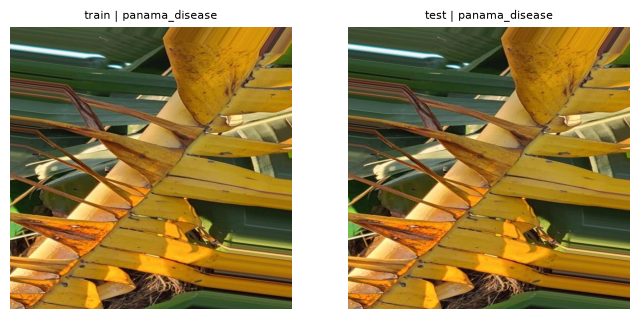

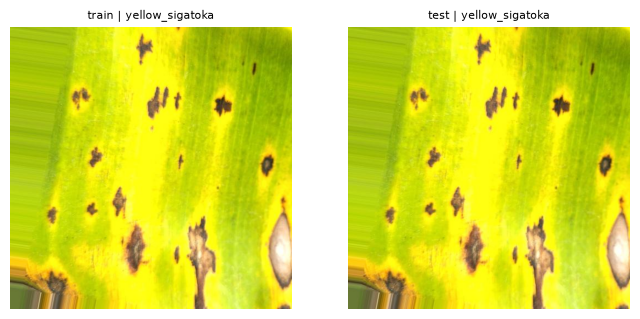

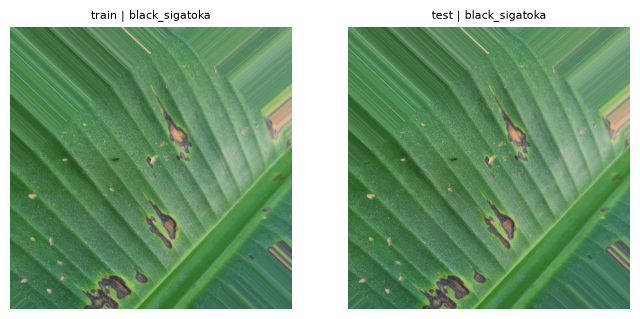

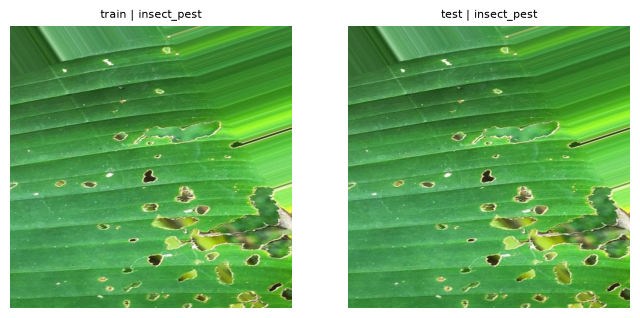

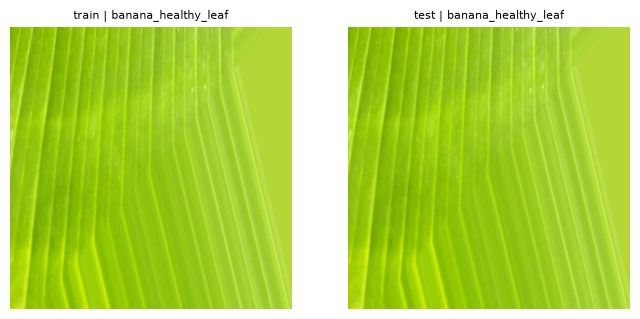

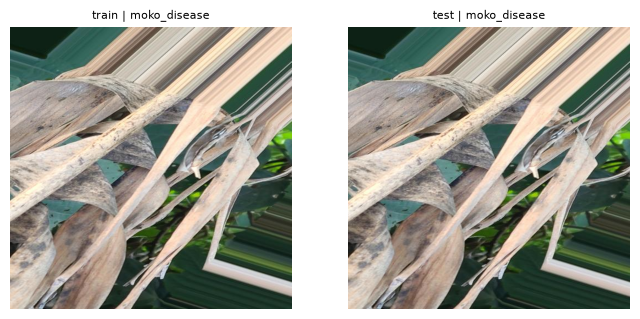

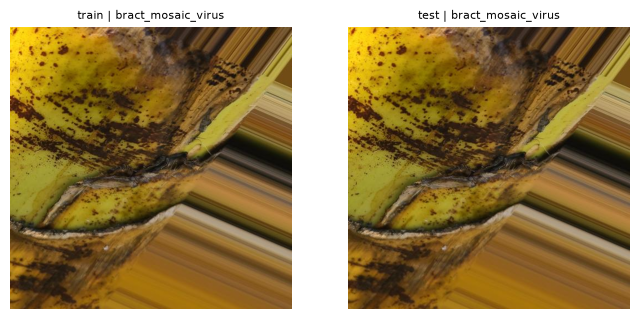

In [41]:
from PIL import Image
for h, g in d.groupby("phash"):
    fig, axes = plt.subplots(1, len(g), figsize=(4*len(g), 4))
    for ax, (_, r) in zip(axes if len(g) > 1 else [axes], g.iterrows()):
        ax.imshow(Image.open(root / r.file)); ax.set_title(f"{r.split} | {r.label}", fontsize=8); ax.axis("off")
    plt.show()

In [42]:
meta = pd.read_csv("../data/raw_metadata.csv")
meta["status"] = "keep"
meta["reason"] = ""

# 1. Find exact-hash duplicate groups
dup_groups = meta[meta.duplicated("phash", keep=False)].groupby("phash")

n_leak = 0
for h, g in dup_groups:
    splits = set(g.split)
    labels = set(g.label)
    if len(labels) > 1:
        # same image under different classes: label conflict, drop all copies
        meta.loc[g.index, ["status", "reason"]] = ["drop", "label conflict"]
    elif splits == {"train", "test"}:
        # same class, copy in both splits: drop the TEST copy(ies)
        test_idx = g[g.split == "test"].index
        meta.loc[test_idx, ["status", "reason"]] = ["drop", "leakage (duplicate of train image)"]
        n_leak += len(test_idx)
    else:
        # same class, same split: keep the first, drop the rest
        meta.loc[g.index[1:], ["status", "reason"]] = ["drop", "duplicate within split"]

print("test images dropped for leakage:", n_leak)
print(meta.status.value_counts())
print(meta[meta.status == "drop"][["file", "split", "label", "reason"]].to_string())

meta.to_csv("../data/raw_metadata.csv", index=False)   # raw image files stay untouched

test images dropped for leakage: 7
status
keep    770
drop      7
Name: count, dtype: int64
                                  file split                label                              reason
700  banana_healthy_leaf/test_0000.png  test  banana_healthy_leaf  leakage (duplicate of train image)
711       black_sigatoka/test_0011.png  test       black_sigatoka  leakage (duplicate of train image)
722   bract_mosaic_virus/test_0022.png  test   bract_mosaic_virus  leakage (duplicate of train image)
733          insect_pest/test_0033.png  test          insect_pest  leakage (duplicate of train image)
744         moko_disease/test_0044.png  test         moko_disease  leakage (duplicate of train image)
755       panama_disease/test_0055.png  test       panama_disease  leakage (duplicate of train image)
766      yellow_sigatoka/test_0066.png  test      yellow_sigatoka  leakage (duplicate of train image)


In [43]:
hashes = {r.file: imagehash.hex_to_hash(r.phash) for r in meta.itertuples()}
files = list(hashes)
close = []
for i in range(len(files)):
    for j in range(i + 1, len(files)):
        d = hashes[files[i]] - hashes[files[j]]      # Hamming distance
        if 0 < d <= 6:
            close.append((files[i], files[j], d))
print(len(close), "near-matches (distance 1-6)")
for c in close[:20]: print(c)

0 near-matches (distance 1-6)


## Block 2

In [44]:
print(meta.groupby(["split", "label"]).size().unstack(0))
print(meta[["width", "height"]].describe())
print(meta["mode"].value_counts())
print(meta.status.value_counts())

split                test  train
label                           
banana_healthy_leaf    11    100
black_sigatoka         11    100
bract_mosaic_virus     11    100
insect_pest            11    100
moko_disease           11    100
panama_disease         11    100
yellow_sigatoka        11    100
       width  height
count  777.0   777.0
mean   512.0   512.0
std      0.0     0.0
min    512.0   512.0
25%    512.0   512.0
50%    512.0   512.0
75%    512.0   512.0
max    512.0   512.0
mode
RGB    777
Name: count, dtype: int64
status
keep    770
drop      7
Name: count, dtype: int64


In [45]:
def sheet(label, n=20, cols=5):
    sub = meta[(meta.label == label) & (meta.status == "keep")].sample(n, random_state=42)
    rows_ = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows_, cols, figsize=(3*cols, 3*rows_))
    for ax, (_, r) in zip(axes.ravel(), sub.iterrows()):
        ax.imshow(Image.open(root / r.file)); ax.set_title(r.file.split("/")[1], fontsize=7); ax.axis("off")
    plt.tight_layout(); plt.savefig(f"results/sheet_{label}.png", dpi=120); plt.show()
    return sub

In [47]:
obs = pd.read_csv("../docs/observations.csv")
print(obs.groupby("label")[["usable_for_scope"]].value_counts())

FileNotFoundError: [Errno 2] No such file or directory: '../docs/observations.csv'